# Visión por Computadora I — TP1
## OpenCV, White Patch e Histogramas
#### Lic. Daniela S. Putrino

In [2]:
%matplotlib inline

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

import os

# Parte 1 — Algoritmo White Patch

In [3]:
# Listamos los archivos disponibles en la carpeta white_patch/

WP_DIR = 'white_patch'
archivos_wp = sorted([f for f in os.listdir(WP_DIR) if f.endswith(('.jpg', '.png'))])

print(f'Imágenes encontradas en "{WP_DIR}/":')
for f in archivos_wp:
    print(f'  - {f}')

Imágenes encontradas en "white_patch/":
  - test_blue.png
  - test_green.png
  - test_red.png
  - wp_blue.jpg
  - wp_green.png
  - wp_green2.jpg
  - wp_red.png
  - wp_red2.jpg


In [4]:
def white_patch(img_bgr: np.ndarray):
    """
    Aplica el algoritmo White Patch a una imagen BGR:
    Cada canal se normaliza por su máximo para corregir el balance de color.
    """
    # Convertimos a float64 para evitar overflow en la operación de escala
    img_float = img_bgr.astype(np.float64)

    # Separamos los canales BGR
    b_channel = img_float[:, :, 0]  
    g_channel = img_float[:, :, 1]  
    r_channel = img_float[:, :, 2]  

    # Encontramos el valor máximo de cada canal en toda la imagen
    b_max = np.max(b_channel)
    g_max = np.max(g_channel)
    r_max = np.max(r_channel)

    # Escalamos cada canal: canal * (255 / max_canal)
    # Guardamos en un array de salida
    img_wp = img_float.copy()

    # Protección contra división por cero (canal completamente negro)
    if r_max > 0:
        img_wp[:, :, 2] = r_channel * (255.0 / r_max)
    if g_max > 0:
        img_wp[:, :, 1] = g_channel * (255.0 / g_max)
    if b_max > 0:
        img_wp[:, :, 0] = b_channel * (255.0 / b_max)

    # Recortamos valores fuera de rango y volvemos a uint8
    np.clip(img_wp, 0, 255, out=img_wp)
    return img_wp.astype(np.uint8)

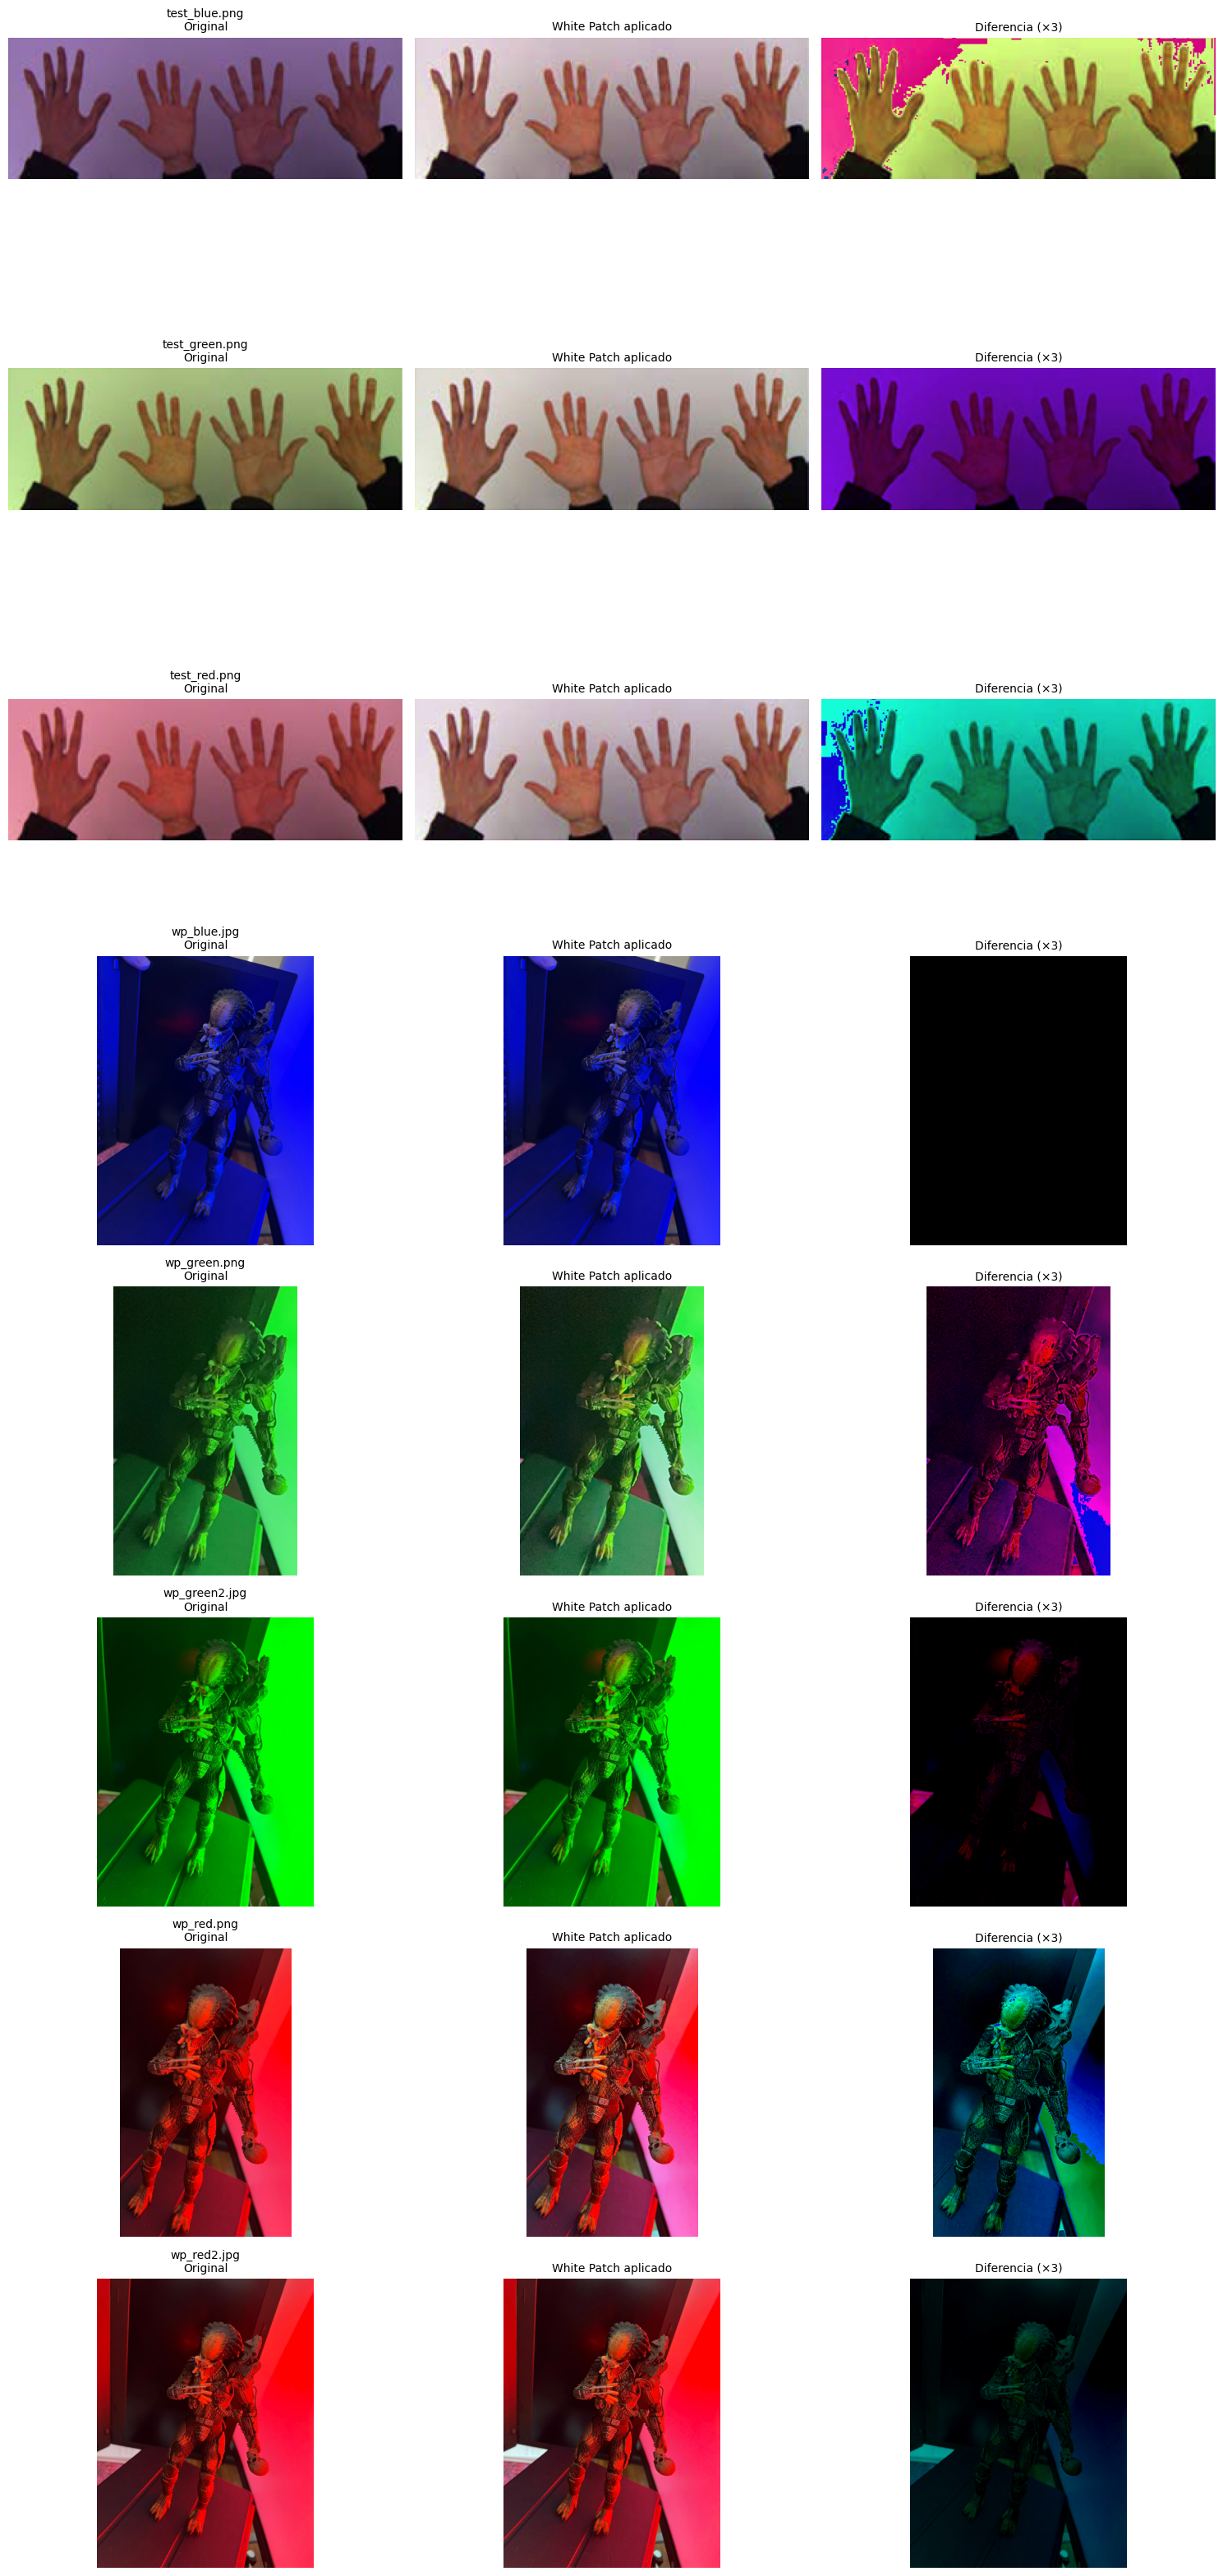

In [5]:
# Aplicamos White Patch a todas las imágenes del directorio

fig, axes = plt.subplots(len(archivos_wp), 3, figsize=(15, 4 * len(archivos_wp)))

# Si hay una sola imagen, axes no es 2D → normalizamos
if len(archivos_wp) == 1:
    axes = [axes]

for idx, nombre_archivo in enumerate(archivos_wp):
    ruta = os.path.join(WP_DIR, nombre_archivo)

    # Cargamos la imagen en color
    img_bgr = cv.imread(ruta)

    if img_bgr is None:
        print(f'No se pudo leer: {ruta}')
        continue

    # Aplicamos el algoritmo White Patch
    img_wp_bgr = white_patch(img_bgr)

    # Convertimos BGR → RGB para mostrar correctamente con matplotlib
    img_rgb     = cv.cvtColor(img_bgr,    cv.COLOR_BGR2RGB)
    img_wp_rgb  = cv.cvtColor(img_wp_bgr, cv.COLOR_BGR2RGB)

    # Calculamos la diferencia para visualizar qué cambió
    diff = np.abs(img_rgb.astype(np.int16) - img_wp_rgb.astype(np.int16)).astype(np.uint8)

    # Mostramos: original | corregida | diferencia
    axes[idx][0].imshow(img_rgb)
    axes[idx][0].set_title(f'{nombre_archivo}\nOriginal', fontsize=10)
    axes[idx][0].axis('off')

    axes[idx][1].imshow(img_wp_rgb)
    axes[idx][1].set_title('White Patch aplicado', fontsize=10)
    axes[idx][1].axis('off')

    axes[idx][2].imshow(diff * 3)  # amplificamos x3 para visualizar mejor
    axes[idx][2].set_title('Diferencia (×3)', fontsize=10)
    axes[idx][2].axis('off')

plt.tight_layout()
plt.show()

## ¿Cuándo falla el algoritmo White Patch?

### Supuesto del algoritmo
El píxel de mayor intensidad en cada canal es blanco puro bajo la iluminación de la escena. Si eso es cierto, normalizar por ese máximo "cancela" el efecto de la fuente de luz.

### Fallas identificadas

**1. Píxel saturado de color (no blanco)**  
Si el píxel más brillante en el canal rojo es, por ejemplo, un objeto rojo saturado (y no un objeto blanco bajo luz roja), el algoritmo tomará ese rojo como referencia de blanco. El resultado será una corrección incorrecta que **introduce un dominante de color opuesto**.

*Ejemplo:* Una imagen con una pelota roja brillante bajo luz blanca. El canal R tendrá su máximo en la pelota roja, no en un objeto blanco, y la corrección distorsionará el balance.

**2. Imágenes sin objetos blancos o muy claros**  
Si la escena no contiene ningún objeto que se acerque al blanco puro, el máximo de cada canal será bajo. La amplificación resultante puede **introducir ruido amplificado**.

**3. Alta correlación entre canales ante iluminación intensa**  
Cuando la iluminación es muy intensa en un solo canal (por ejemplo, luz muy roja), el máximo del canal R estará cerca de 255 y los canales G y B estarán muy amplificados. Esta amplificación puede introducir ruido y pérdida de información.

**4. Imágenes de bajo contraste o poco rango dinámico**  
Si varios canales tienen maximos similares (imagen grisácea), White Patch produce poca corrección y el resultado no mejora visiblemente.

### Conclusión
El algoritmo White Patch es una solución **simple, rápida y sin parámetros** para corrección de balance de color. Funciona bien cuando la escena contiene al menos una superficie blanca o muy clara. Sin embargo, **no es robusto** ante escenas sin blancos reales, objetos saturados o iluminación extremadamente monocromática.

# Parte 2

In [6]:
# Cargamos las imágenes en escala de grises
# cv.IMREAD_GRAYSCALE convierte directamente a un solo canal

img1 = cv.imread('img1_tp.png', cv.IMREAD_GRAYSCALE)
img2 = cv.imread('img2_tp.png', cv.IMREAD_GRAYSCALE)

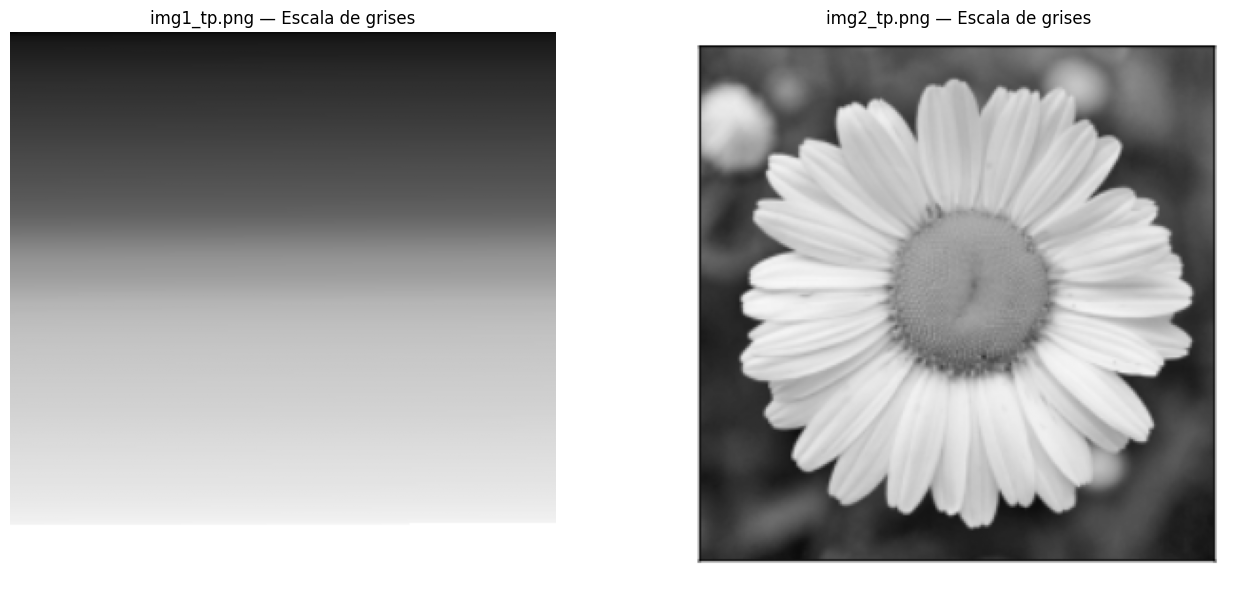

In [7]:
# Visualizamos las dos imágenes en escala de grises

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(img1, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('img1_tp.png — Escala de grises', fontsize=12)
axes[0].axis('off')

axes[1].imshow(img2, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('img2_tp.png — Escala de grises', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

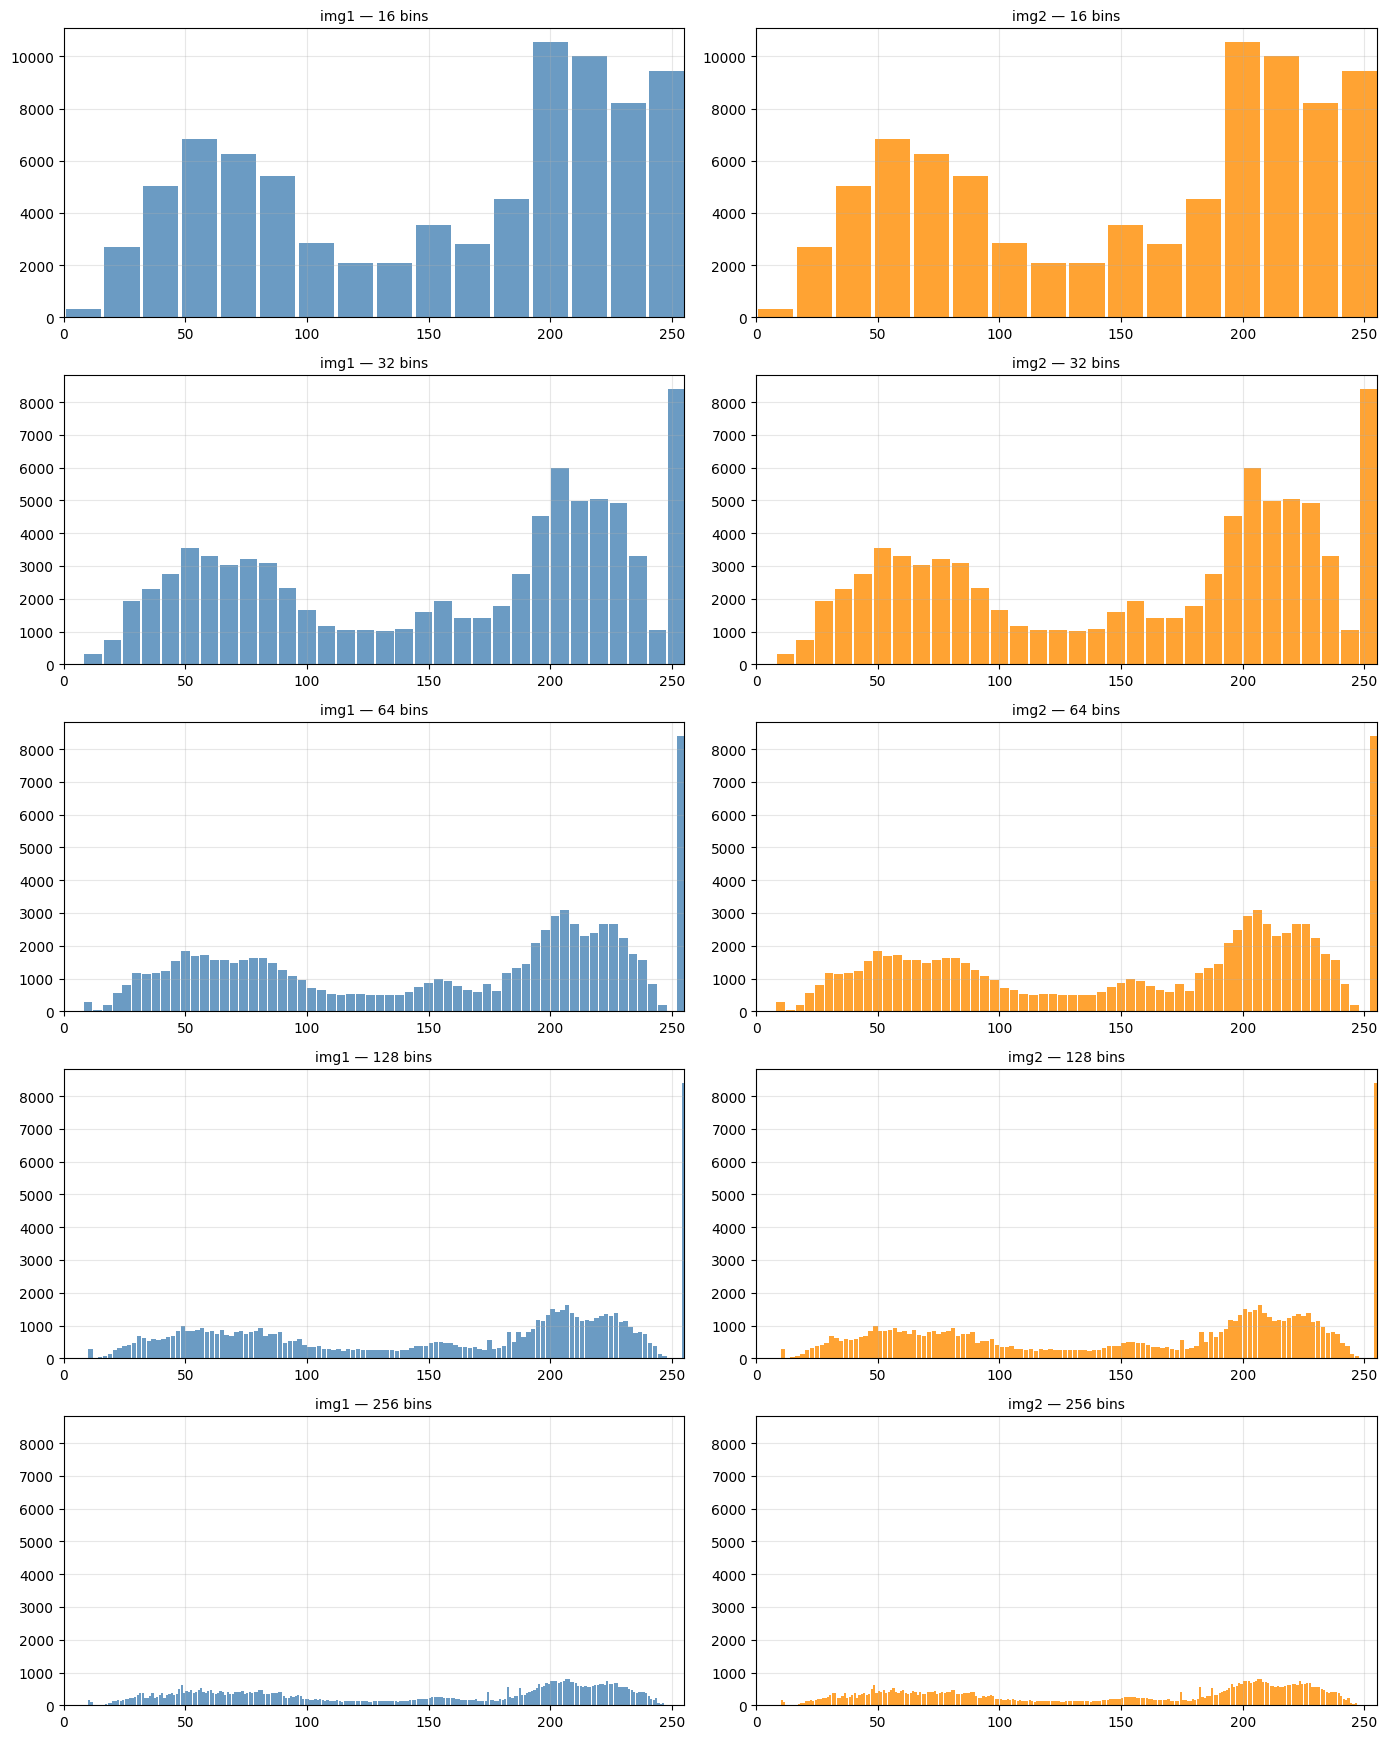

In [8]:
# Comparamos distintos números de bins para ver la sensibilidad de la elección y el compromiso entre resolución y compactacióin

bins_a_probar = [16, 32, 64, 128, 256]

fig, axes = plt.subplots(len(bins_a_probar), 2,
                         figsize=(14, 3.5 * len(bins_a_probar)))

for i, n_bins in enumerate(bins_a_probar):
    h1, be = np.histogram(img1.ravel(), n_bins, [0, 256])
    h2, _  = np.histogram(img2.ravel(), n_bins, [0, 256])
    bc = (be[:-1] + be[1:]) / 2

    axes[i][0].bar(bc, h1, width=256/n_bins * 0.9,
                   color='steelblue', alpha=0.8)
    axes[i][0].set_title(f'img1 — {n_bins} bins', fontsize=10)
    axes[i][0].set_xlim(0, 255)
    axes[i][0].grid(True, alpha=0.3)

    axes[i][1].bar(bc, h2, width=256/n_bins * 0.9,
                   color='darkorange', alpha=0.8)
    axes[i][1].set_title(f'img2 — {n_bins} bins', fontsize=10)
    axes[i][1].set_xlim(0, 255)
    axes[i][1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Elección del número de bins:

# Para este análisis usamos 64 bins, que permite ver la estructura de la distribución con suficiente detalle. Además, 64 valores es un descriptor razonablemente compacto si se lo quisiera usar como feature.
# De todas maneras, al probar con 32 bins para estos ejemplos de imágenes sencillas en escala de grises no se observa gran pérdida de la estructura en el histograma, con lo cual puede ser una buena elección también.

N_BINS = 64

hist1, bin_edges1 = np.histogram(img1.ravel(), N_BINS, [0, 256])
hist2, bin_edges2 = np.histogram(img2.ravel(), N_BINS, [0, 256])

# Centroides de los bins para graficar
bin_centers = (bin_edges1[:-1] + bin_edges1[1:]) / 2

print(f'Número de bins elegido: {N_BINS}')

Número de bins elegido: 64


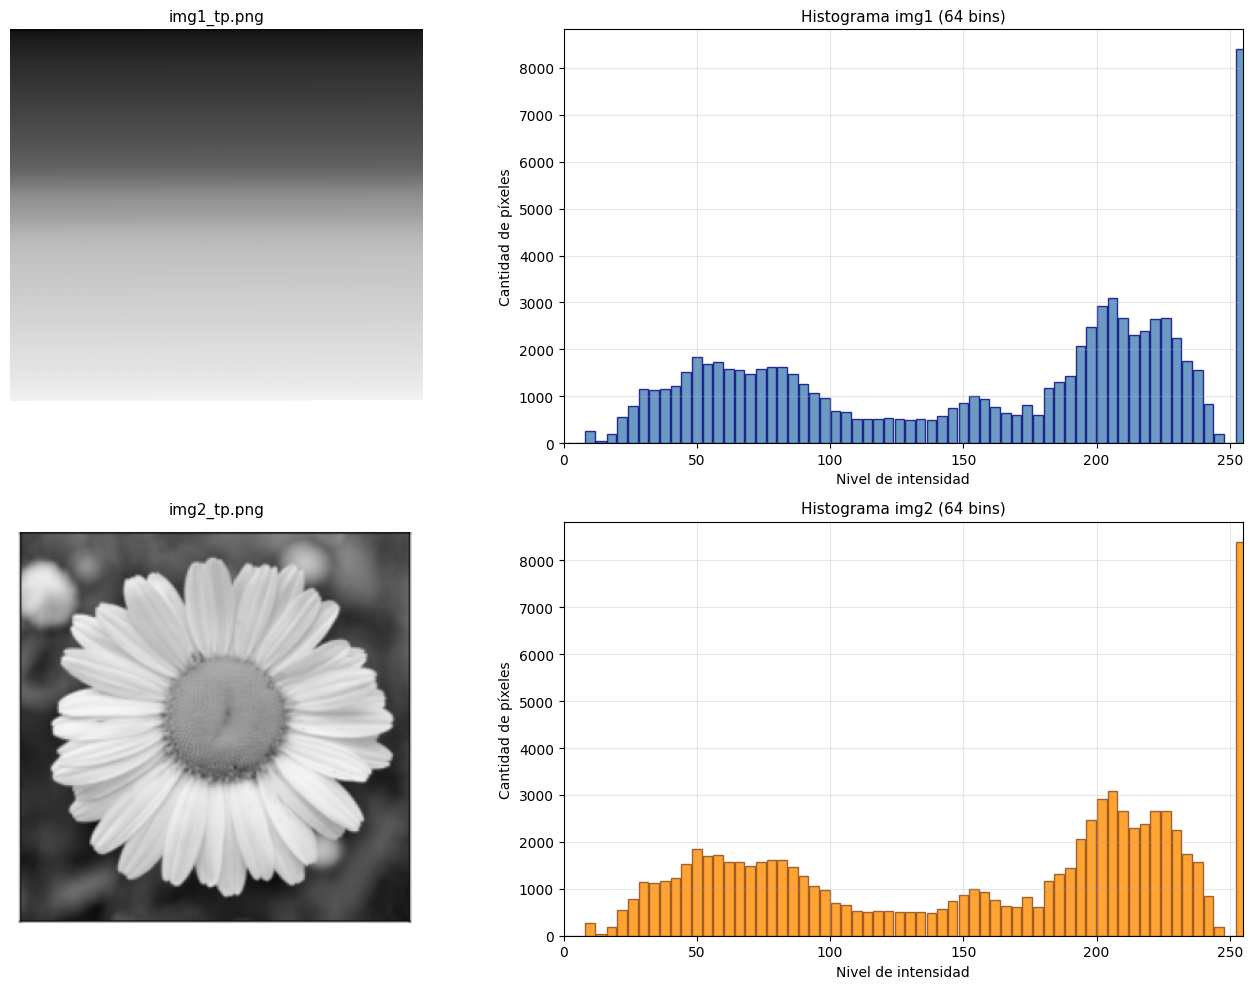

In [10]:
# Visualizamos los histogramas individualmente

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Imagen 1 + su histograma
axes[0][0].imshow(img1, cmap='gray', vmin=0, vmax=255)
axes[0][0].set_title('img1_tp.png', fontsize=11)
axes[0][0].axis('off')

axes[0][1].bar(bin_centers, hist1, width=256/N_BINS * 0.9,
               color='steelblue', edgecolor='navy', alpha=0.8)
axes[0][1].set_title(f'Histograma img1 ({N_BINS} bins)', fontsize=11)
axes[0][1].set_xlabel('Nivel de intensidad')
axes[0][1].set_ylabel('Cantidad de píxeles')
axes[0][1].set_xlim(0, 255)
axes[0][1].grid(True, alpha=0.3)

# Imagen 2 + su histograma
axes[1][0].imshow(img2, cmap='gray', vmin=0, vmax=255)
axes[1][0].set_title('img2_tp.png', fontsize=11)
axes[1][0].axis('off')

axes[1][1].bar(bin_centers, hist2, width=256/N_BINS * 0.9,
               color='darkorange', edgecolor='saddlebrown', alpha=0.8)
axes[1][1].set_title(f'Histograma img2 ({N_BINS} bins)', fontsize=11)
axes[1][1].set_xlabel('Nivel de intensidad')
axes[1][1].set_ylabel('Cantidad de píxeles')
axes[1][1].set_xlim(0, 255)
axes[1][1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Ambas imágenes ocupan casi el rango completo [0, 255], lo que indica buen rango dinámico y brillo moderado-alto, alto contraste y uso eficiente del espectro de intensidades. La distribución está desplazada hacia tonos medios-claros.

Al comparar los histogramas se orberva que son idénticos. Es decir que ambas imágenes tienen la misma distribución de intensidades de píxeles.
Sin embargo, esto no implica que las imágenes sean iguales visualmente, de hecho se observa que no lo son. Esta es limitación más importante del histograma como descriptor, que no captura información espacial. Por este motivo, no sería de utilidad como "feature" para el entrenamiento de un modelo de clasificación/detección de imágenes, dado que en este caso no las diferenciaría.


## Información extra relevada para el análisis de histogramas como "features":
### Ventajas del histograma como descriptor

**1. Invarianza a la posición espacial (translación)**
El histograma no depende de dónde esté ubicado un objeto dentro de la imagen. Dos imágenes de la misma escena con el objeto desplazado tendrán histogramas similares. Útil cuando la posición no es relevante.

**2. Compacidad**
Un histograma de 64 bins representa toda la imagen en solo 64 valores. Esta reducción de dimensionalidad es valiosa para entrenar modelos eficientes.

**3. Facilidad de comparación**
Se pueden medir similitudes entre imágenes usando métricas estándar (correlación, chi-cuadrado) sobre los histogramas.

### Limitaciones

**1. Pérdida de información espacial**
El histograma no sabe dónde están los píxeles, solo cuántos hay de cada intensidad. Dos imágenes completamente distintas pueden tener histogramas idénticos.

**2. Sensibilidad a cambios de iluminación**
Un cambio global de iluminación desplaza todo el histograma. Esto puede confundir a un clasificador aunque el objeto sea el mismo.

**3. No distingue la estructura interna**
Para detección de objetos específicos, el histograma global es insuficiente. Histogramas locales capturan estructura espacial y son mucho más efectivos.

### Conclusión

Los histogramas **pueden ser útiles como features** en casos donde:
- Las clases difieren principalmente en su distribución de brillo (imágenes médicas, distintos tipos de textura).
- Se combinen con descriptores espaciales (SIFT, ORB, HoG) para enriquecer la representación.
- Se usen histogramas 2D multi-canal que agregan discriminación cruzada entre canales.

Para clasificación/detección general de objetos en imágenes complejas, los histogramas globales solos son insuficientes (si las imágenes son distintas visualmente pero tienen igual histograma, ningún modelo basado solo en histogramas podría distinguirlas.)